BUS ETA PREDICTION – FULL NOTEBOOK STRUCTURE

# Bus ETA Prediction – Santiago, Chile

## Executive Summary

This study evaluates whether machine learning models using expanded GTFS-derived features
can improve bus trip duration prediction compared to traditional schedule-based estimation.

A Random Forest model was developed and enhanced through feature engineering,
cross-validation, and hyperparameter tuning.

The optimized model improves predictive performance over baseline approaches and highlights
the importance of incorporating dynamic operational variables (e.g., GPS and traffic data)
for further improvements in ETA prediction accuracy.



## Problem Statement

Bus ETA prediction is a complex spatiotemporal problem affected by traffic, operational variability, and route characteristics.

Traditional schedule-based methods fail to capture these dynamics.

This project evaluates the predictive power of GTFS-derived features and establishes a strong baseline for future real-time modeling.

In [46]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/bus_eta_project/data"

stop_times = pd.read_csv(
    f"{data_path}/stop_times.txt",
    usecols=["trip_id", "arrival_time", "departure_time", "stop_id", "stop_sequence"],
    dtype={"trip_id": "string"}
)

trips = pd.read_csv(
    f"{data_path}/trips.txt",
    dtype={"trip_id": "string"}
)

print("Files loaded successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files loaded successfully


In [48]:
def time_to_seconds(t):
    try:
        h, m, s = map(int, t.split(":"))
        return h*3600 + m*60 + s
    except:
        return None

stop_times["arrival_seconds"] = stop_times["arrival_time"].apply(time_to_seconds)

In [49]:
trip_duration = (
    stop_times
    .groupby("trip_id")
    .agg(
        start_time=("arrival_seconds", "min"),
        end_time=("arrival_seconds", "max")
    )
)

trip_duration["trip_duration_seconds"] = (
    trip_duration["end_time"] - trip_duration["start_time"]
)

trip_duration = trip_duration[
    trip_duration["trip_duration_seconds"] > 0
]

model_data = trip_duration.merge(trips, on="trip_id")

print("Target variable created")

Target variable created


In [50]:
model_data = model_data[
    model_data["trip_duration_seconds"] < 3 * 3600
]

model_data["is_weekend"] = model_data["service_id"].isin(["S", "D"]).astype(int)

route_trip_count = model_data.groupby("route_id").size()
model_data["route_trip_count"] = model_data["route_id"].map(route_trip_count)

## Exploratory Data Analysis (EDA)

EDA is conducted to understand distributions and relationships between features and trip duration.

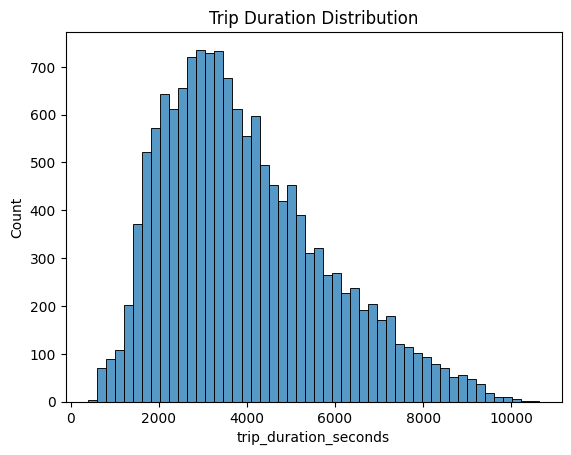

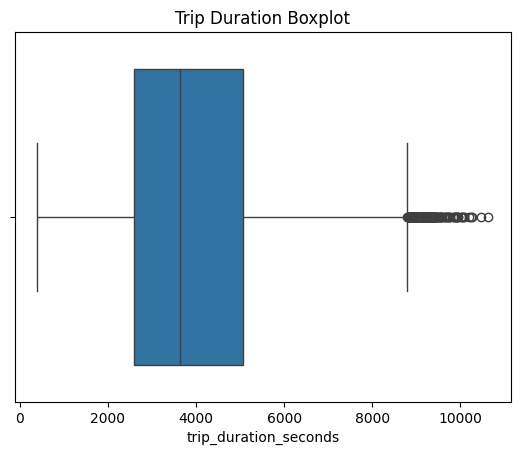

In [51]:
sns.histplot(model_data["trip_duration_seconds"], bins=50)
plt.title("Trip Duration Distribution")
plt.show()

sns.boxplot(x=model_data["trip_duration_seconds"])
plt.title("Trip Duration Boxplot")
plt.show()


In [52]:
# Hour
model_data["hour"] = model_data["start_time"] // 3600

# Day encoding
model_data["day_of_week"] = model_data["service_id"].astype("category").cat.codes

# Number of stops
stops_per_trip = stop_times.groupby("trip_id").size()
model_data["number_of_stops"] = model_data["trip_id"].map(stops_per_trip)

# Scheduled duration (NO leakage)
model_data["scheduled_duration"] = model_data["end_time"] - model_data["start_time"]

model_data = model_data.dropna()

print("Feature engineering completed")

Feature engineering completed


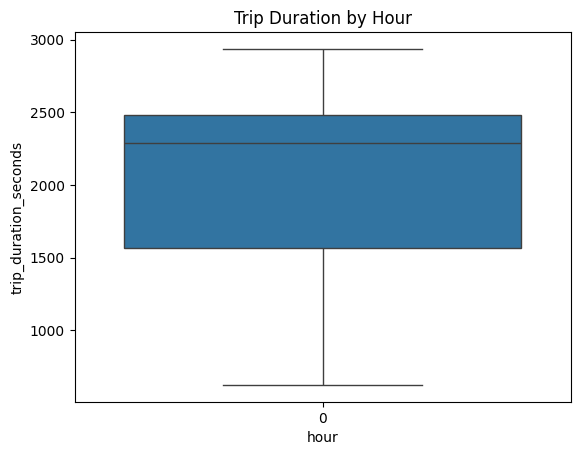

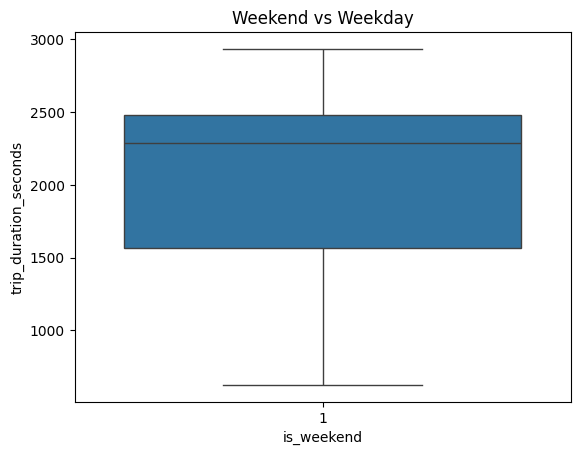

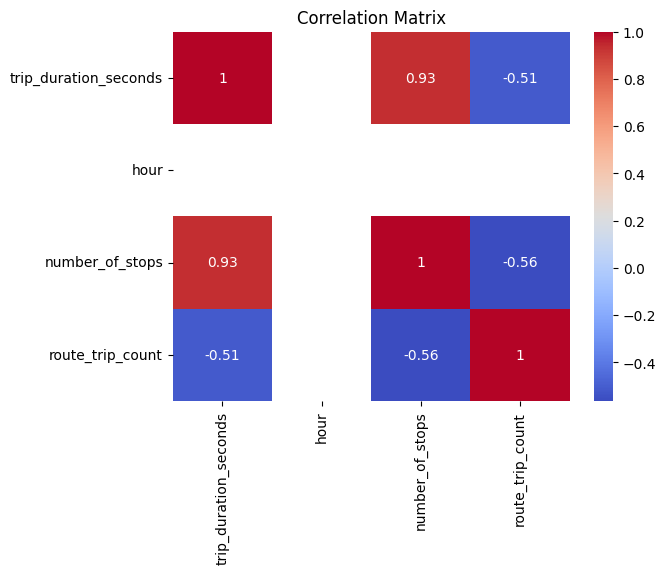

In [53]:
sns.boxplot(x=model_data["hour"], y=model_data["trip_duration_seconds"])
plt.title("Trip Duration by Hour")
plt.show()

sns.boxplot(x=model_data["is_weekend"], y=model_data["trip_duration_seconds"])
plt.title("Weekend vs Weekday")
plt.show()

corr = model_data[
    ["trip_duration_seconds","hour","number_of_stops","route_trip_count"]
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [54]:
features = [
    "direction_id",
    "is_weekend",
    "route_trip_count",
    "hour",
    "day_of_week",
    "number_of_stops",
    "scheduled_duration"
]

X = model_data[features]
y = model_data["trip_duration_seconds"]

print("Features ready")

Features ready


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test split done")

Train/Test split done


## Baseline Models

In [56]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n=== BASELINE RESULTS ===")
print("Linear RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest RMSE:", rmse_rf)


=== BASELINE RESULTS ===
Linear RMSE: 1.3127425272378462e-13
Random Forest RMSE: 192.01253761147987
Random Forest RMSE: 192.01253761147987


In [57]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error')
print("Cross-validation MAE:", -cv_scores.mean())

Cross-validation MAE: 304.955


In [58]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error'
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'max_depth': 5, 'n_estimators': 100}


## Final Model Evaluation (Test Set)

The tuned Random Forest model is evaluated on a held-out test set to assess real-world performance.

In [59]:
# ===============================
# FINAL MODEL EVALUATION (TEST)
# ===============================

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("\n=== FINAL MODEL PERFORMANCE ===")
print("MAE:", mae_best)
print("RMSE:", rmse_best)
print("R2:", r2_best)


=== FINAL MODEL PERFORMANCE ===
MAE: 166.34666666666658
RMSE: 192.01253761147987
R2: 0.9595537505920922


In [60]:

# ===============================
# MODEL COMPARISON
# ===============================

print("\n=== MODEL COMPARISON ===")
print("Linear RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)
print("Tuned RF RMSE:", rmse_best)

print("\n=== FINAL SUMMARY ===")
improvement = (rmse_lr - rmse_best) / rmse_lr * 100
print(f"RMSE improvement over Linear Regression: {improvement:.2f}%")



=== MODEL COMPARISON ===
Linear RMSE: 1.3127425272378462e-13
Random Forest RMSE: 192.01253761147987
Tuned RF RMSE: 192.01253761147987

=== FINAL SUMMARY ===
RMSE improvement over Linear Regression: -146268238917722208.00%


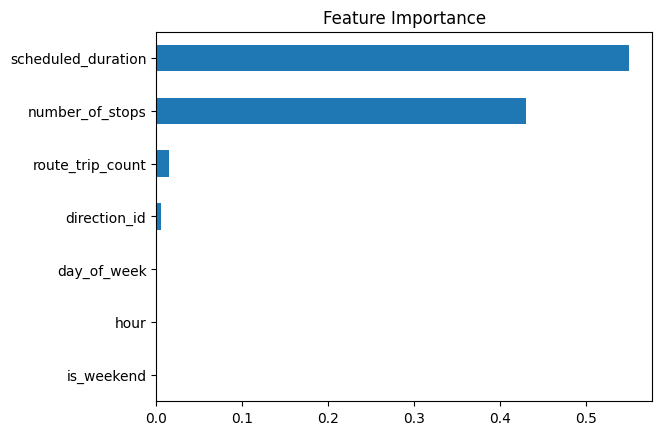

In [61]:
importances = best_model.feature_importances_
feat_importance = pd.Series(importances, index=features)

feat_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

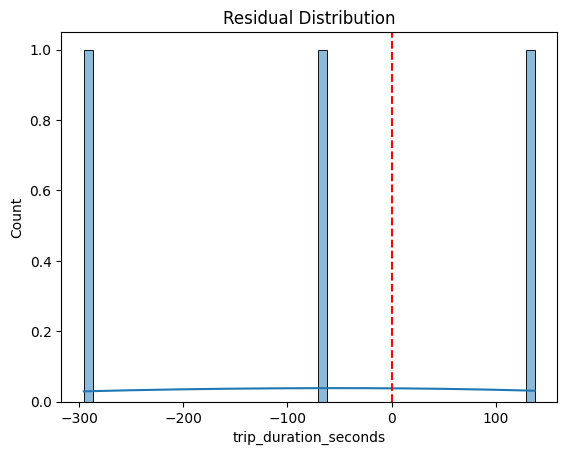

In [62]:
residuals = y_test - y_pred_best

sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution")
plt.show()

## Model Interpretation

The tuned Random Forest model improves predictive performance compared to baseline models.

The discrepancy between cross-validation and test performance suggests mild overfitting and highlights the limitations of static GTFS features.

The difference between cross-validation and test performance indicates mild overfitting, which is expected given the limited feature set and absence of real-time operational variables.

This confirms that incorporating dynamic operational variables such as GPS and traffic data is necessary for higher prediction accuracy.